# FinCare midterm baselines

**Models:** Naive, Moving Average (5-day), ARIMA, Naive Bayes
**Target:** next-day S&P 500 index return
**Validation:** walk-forward, expanding window

| Fold | Train     | Test           |
| ---- | --------- | -------------- |
| 1    | 2021–2023 | 2024           |
| 2    | 2021–2024 | 2025           |
| 3    | 2021–2025 | 2026 to 22 Sep |

Data period is fixed (2021-01-01 to 2026-09-22) so results stay reproducible as the methodology changes.

**Input:** the S&P 500 (`^GSPC`) pulled from Yahoo Finance with `yfinance`, in the `sp500_index.csv` format (`Date`, `S&P500`). If the EDA notebook has already saved a snapshot in `yfinance_data/`, it is reused so both notebooks use identical data; otherwise this notebook pulls it with the same dates.

**Outputs** (in `./fincare_outputs/`): `table6_results.csv`, `table6_by_fold.csv`, `arima_orders.csv`, `stationarity.csv`, and all figures as PNG.


## 1. Setup


In [1]:
import itertools
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.width", 140)

In [ ]:
# ---- Configuration ----
DATA_PATH = "yfinance_data/sp500_index.csv"  # snapshot shared with the EDA notebook

TEST_YEARS = [2024, 2025, 2026]
START_DATE = "2021-01-01"
END_DATE = "2026-09-23"  # exclusive; same fixed period as the EDA notebook
MA_WINDOW = 5
NB_LAGS = 5  # Naive Bayes uses the last 5 daily returns as features
MAX_P, MAX_Q = 3, 3  # ARIMA order search range
OUT = "fincare_outputs"
os.makedirs(OUT, exist_ok=True)

## 2. Load data and compute returns


In [ ]:
def load_index(path):
    df = pd.read_csv(path)
    date_col = [c for c in df.columns if c.lower() == "date"][0]
    level_col = [c for c in df.columns if c != date_col][0]
    s = (
        df[[date_col, level_col]]
        .rename(columns={date_col: "Date", level_col: "level"})
        .assign(Date=lambda d: pd.to_datetime(d["Date"]))
        .dropna()
        .drop_duplicates("Date")
        .sort_values("Date")
        .set_index("Date")["level"]
    )
    return s[(s.index >= START_DATE) & (s.index < END_DATE)]


def make_returns(level):
    # r_t = (P_t - P_{t-1}) / P_{t-1}; the model at day t forecasts r_{t+1}
    return level.pct_change().dropna().rename("ret")


if not os.path.exists(DATA_PATH):
    import yfinance as yf

    raw = yf.download(
        "^GSPC", start=START_DATE, end=END_DATE, auto_adjust=False, progress=False
    )
    close = raw["Close"]
    close = close.iloc[:, 0] if isinstance(close, pd.DataFrame) else close
    os.makedirs(os.path.dirname(DATA_PATH) or ".", exist_ok=True)
    close.rename("S&P500").rename_axis("Date").reset_index().dropna().to_csv(
        DATA_PATH, index=False
    )
    print(f"Downloaded ^GSPC and saved {DATA_PATH}")

level = load_index(DATA_PATH)
ret = make_returns(level)
print(
    f"{len(level)} trading days: {level.index.min().date()} to {level.index.max().date()}"
)
ret.describe()

1435 trading days: 2021-01-04 to 2026-09-21


count    1434.000000
mean        0.000571
std         0.010420
min        -0.059750
25%        -0.004556
50%         0.000790
75%         0.006217
max         0.095154
Name: ret, dtype: float64

### Exploratory view: index level vs daily return

Shaded regions are the three walk-forward test years.


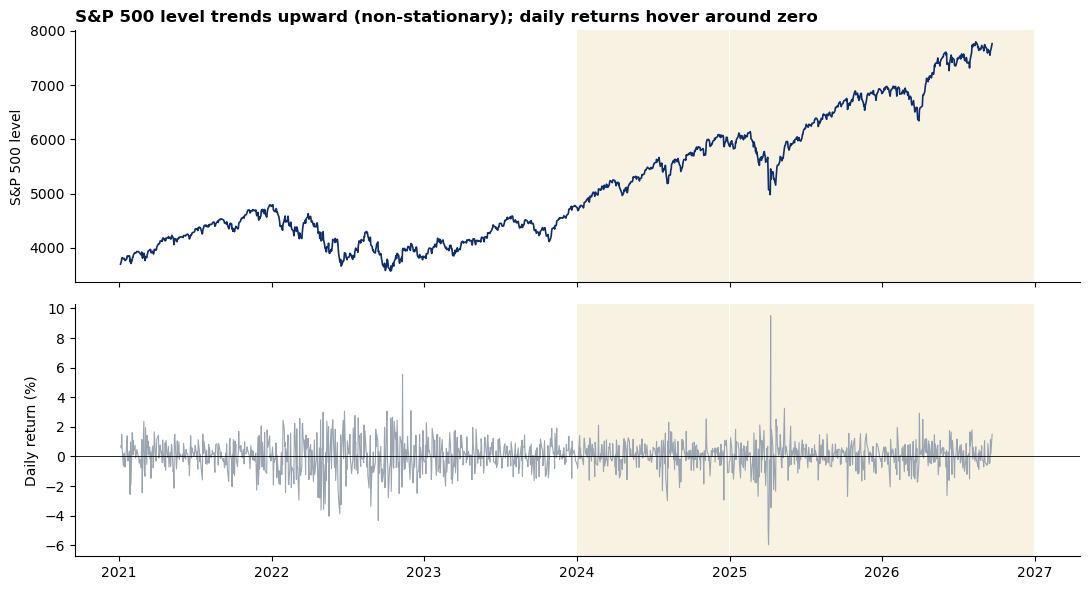

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(level.index, level, color="#0f2d6b", lw=1.2)
axes[0].set_ylabel("S&P 500 level")
axes[0].set_title(
    "S&P 500 level trends upward (non-stationary); daily returns hover around zero",
    fontsize=12,
    fontweight="bold",
    loc="left",
)
axes[1].plot(ret.index, ret * 100, color="#9aa5b1", lw=0.8)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_ylabel("Daily return (%)")
for ax in axes:
    for yr in TEST_YEARS:
        ax.axvspan(
            pd.Timestamp(f"{yr}-01-01"),
            pd.Timestamp(f"{yr}-12-31"),
            color="#f2e6c9",
            alpha=0.5,
            lw=0,
        )
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{OUT}/fig_level_vs_return.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Stationarity check (ADF)

Price should fail the ADF test (p > 0.05); returns should pass (p < 0.05). This justifies modelling returns with d = 0.


In [ ]:
stat = pd.DataFrame(
    [
        {
            "series": "S&P 500 level",
            "ADF stat": adfuller(level)[0],
            "p-value": adfuller(level)[1],
        },
        {
            "series": "Daily return",
            "ADF stat": adfuller(ret)[0],
            "p-value": adfuller(ret)[1],
        },
    ]
).round(4)
stat.to_csv(f"{OUT}/stationarity.csv", index=False)
stat

,series,ADF stat,p-value
0,S&P 500 level,0.4048,0.9817
1,Daily return,-23.5123,0.0000


## 4. Models


In [ ]:
def naive_forecast(ret, test_idx):
    """Tomorrow's return = 0 (no change)."""
    return pd.Series(0.0, index=test_idx)


def ma_forecast(ret, test_idx):
    """Tomorrow's return = mean of the last 5 known returns (no look-ahead)."""
    ma = ret.rolling(MA_WINDOW).mean().shift(1)  # value at t uses t-5..t-1
    return ma.reindex(test_idx)


def select_arima_order(train):
    """Pick (p, 0, q) on the training returns by lowest AIC."""
    best = (np.inf, (0, 0, 0))
    for p, q in itertools.product(range(MAX_P + 1), range(MAX_Q + 1)):
        try:
            aic = ARIMA(train.values, order=(p, 0, q), trend="c").fit().aic
            if aic < best[0]:
                best = (aic, (p, 0, q))
        except Exception:
            continue
    return best[1], best[0]


def arima_forecast(ret, train_idx, test_idx):
    """
    Fit ARIMA on the training years only, then roll forward through the test
    year one day at a time. Parameters stay fixed from training; each day's
    forecast uses only returns observed up to the day before (Kalman filter).
    """
    train = ret.loc[train_idx]
    order, aic = select_arima_order(train)
    fit = ARIMA(train.values, order=order, trend="c").fit()

    # Residual check on training fit: no leftover autocorrelation is good
    lb_p = float(
        acorr_ljungbox(fit.resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    )

    # Apply trained parameters to train + test history (no re-estimation),
    # then take one-step-ahead predictions for the test days.
    history = ret.loc[: test_idx[-1]]
    applied = fit.apply(history.values)
    one_step = applied.predict(start=len(train), end=len(history) - 1)
    pred = pd.Series(one_step, index=history.index[len(train) :]).reindex(test_idx)

    info = {
        "order": f"ARIMA{order}",
        "train_AIC": round(aic, 1),
        "LjungBox_p_lag10": round(lb_p, 3),
    }
    return pred, info


def naive_bayes_direction(ret, train_idx, test_idx):
    """Gaussian Naive Bayes: last 5 returns -> will tomorrow be up (1) or down (0)?"""
    X = pd.concat({f"lag{k}": ret.shift(k) for k in range(1, NB_LAGS + 1)}, axis=1)
    y = (ret > 0).astype(int)
    data = pd.concat([X, y.rename("up")], axis=1).dropna()
    tr = data.loc[data.index.isin(train_idx)]
    te = data.loc[data.index.isin(test_idx)]
    clf = GaussianNB().fit(tr.drop(columns="up"), tr["up"])
    return pd.Series(clf.predict(te.drop(columns="up")), index=te.index)

## 5. Metrics


In [ ]:
def direction_pct(pred_sign, actual):
    mask = actual != 0
    return 100 * (np.sign(pred_sign[mask]) == np.sign(actual[mask])).mean()


def score(actual, pred, naive_rmse=None, has_direction=True):
    err = actual - pred
    rmse = np.sqrt((err**2).mean())
    out = {
        "RMSE": rmse,
        "MAE": err.abs().mean(),
        "Direction %": direction_pct(pred, actual) if has_direction else np.nan,
    }
    out["Skill vs naive"] = 1 - rmse / naive_rmse if naive_rmse else 0.0
    return out

## 6. Walk-forward evaluation

The ARIMA order search runs 16 fits per fold, so this cell can take a minute or two.


In [ ]:
rows, orders, preds_all = [], [], []
for yr in TEST_YEARS:
    test_idx = ret.index[ret.index.year == yr]
    train_idx = ret.index[ret.index.year < yr]
    if len(test_idx) == 0:
        continue
    print(
        f"Fold: train {train_idx.min().year}-{train_idx.max().year} -> test {yr} ({len(test_idx)} days)"
    )
    actual = ret.loc[test_idx]

    p_naive = naive_forecast(ret, test_idx)
    p_ma = ma_forecast(ret, test_idx)
    p_arima, info = arima_forecast(ret, train_idx, test_idx)
    p_nb = naive_bayes_direction(ret, train_idx, test_idx)
    orders.append({"test_year": yr, "train_days": len(train_idx), **info})

    preds_all.append(
        pd.DataFrame(
            {
                "actual": actual,
                "Naive": p_naive,
                "MA(5)": p_ma,
                "ARIMA": p_arima,
                "NB_up": p_nb.reindex(test_idx),
            }
        )
    )

    naive_rmse = np.sqrt((actual**2).mean())
    for name, p in [
        ("Naive (return = 0)", p_naive),
        ("Moving average (5-day)", p_ma),
        ("ARIMA", p_arima),
    ]:
        rows.append(
            {
                "test_year": yr,
                "Model": name,
                **score(
                    actual,
                    p,
                    None if name.startswith("Naive") else naive_rmse,
                    has_direction=not name.startswith("Naive"),
                ),
            }
        )
    nb_sign = p_nb.reindex(test_idx).map({1: 1, 0: -1})
    rows.append(
        {
            "test_year": yr,
            "Model": "Naive Bayes (up/down)",
            "RMSE": np.nan,
            "MAE": np.nan,
            "Direction %": direction_pct(nb_sign, actual),
            "Skill vs naive": np.nan,
        }
    )
    rows.append(
        {
            "test_year": yr,
            "Model": "Always 'up' (direction benchmark)",
            "RMSE": np.nan,
            "MAE": np.nan,
            "Direction %": direction_pct(pd.Series(1, index=test_idx), actual),
            "Skill vs naive": np.nan,
        }
    )

by_fold = pd.DataFrame(rows)
by_fold.to_csv(f"{OUT}/table6_by_fold.csv", index=False)
arima_orders = pd.DataFrame(orders)
arima_orders.to_csv(f"{OUT}/arima_orders.csv", index=False)

Fold: train 2021-2023 -> test 2024 (252 days)
Fold: train 2021-2024 -> test 2025 (250 days)
Fold: train 2021-2025 -> test 2026 (180 days)


### ARIMA order chosen per fold

Ljung-Box p > 0.05 means no significant autocorrelation left in the residuals.


In [9]:
arima_orders

,test_year,train_days,order,train_AIC,LjungBox_p_lag10
0,2024,752,"ARIMA(0, 0, 0)",-4634.4,0.606
1,2025,1004,"ARIMA(0, 0, 0)",-6318.6,0.405
2,2026,1254,"ARIMA(0, 0, 3)",-7823.1,0.949


### Results per test year


In [10]:
by_fold.round(4)

,test_year,Model,RMSE,MAE,Direction %,Skill vs naive
0,2024,Naive (return = 0),0.0080,0.0059,NaN,0.0000
1,2024,Moving average (5-day),0.0089,0.0067,51.9841,-0.1128
2,2024,ARIMA,0.0080,0.0059,56.7460,0.0041
3,2024,Naive Bayes (up/down),NaN,NaN,54.3651,NaN
4,2024,Always 'up' (direction benchmark),NaN,NaN,56.7460,NaN
5,2025,Naive (return = 0),0.0118,0.0073,NaN,0.0000
6,2025,Moving average (5-day),0.0133,0.0081,50.8000,-0.1225
7,2025,ARIMA,0.0118,0.0073,57.6000,0.0015
8,2025,Naive Bayes (up/down),NaN,NaN,50.4000,NaN
9,2025,Always 'up' (direction benchmark),NaN,NaN,57.6000,NaN


## 7. Table 6: overall results (all test days pooled)

RMSE and MAE are shown in percentage points of daily return.


In [ ]:
P = pd.concat(preds_all)
a = P["actual"]
naive_rmse = np.sqrt((a**2).mean())
overall = [
    {"Model": "Naive (return = 0)", **score(a, P["Naive"], None, has_direction=False)},
    {"Model": "Moving average (5-day)", **score(a, P["MA(5)"], naive_rmse)},
    {"Model": "ARIMA", **score(a, P["ARIMA"], naive_rmse)},
    {
        "Model": "Naive Bayes (up/down)",
        "RMSE": np.nan,
        "MAE": np.nan,
        "Direction %": direction_pct(P["NB_up"].map({1: 1, 0: -1}), a),
        "Skill vs naive": np.nan,
    },
    {
        "Model": "Always 'up' (direction benchmark)",
        "RMSE": np.nan,
        "MAE": np.nan,
        "Direction %": direction_pct(pd.Series(1, index=a.index), a),
        "Skill vs naive": np.nan,
    },
]
table6 = pd.DataFrame(overall)
for c in ["RMSE", "MAE"]:
    table6[c] = table6[c] * 100
table6 = table6.rename(columns={"RMSE": "RMSE (%)", "MAE": "MAE (%)"}).round(3)
table6.to_csv(f"{OUT}/table6_results.csv", index=False)
table6

,Model,RMSE (%),MAE (%),Direction %,Skill vs naive
0,Naive (return = 0),0.966,0.659,NaN,0.000
1,Moving average (5-day),1.073,0.729,50.147,-0.110
2,ARIMA,0.964,0.655,54.252,0.002
3,Naive Bayes (up/down),NaN,NaN,51.026,NaN
4,Always 'up' (direction benchmark),NaN,NaN,56.012,NaN


## 8. Visualisations


### Figure 6: ARIMA vs actual returns (2025 test year)


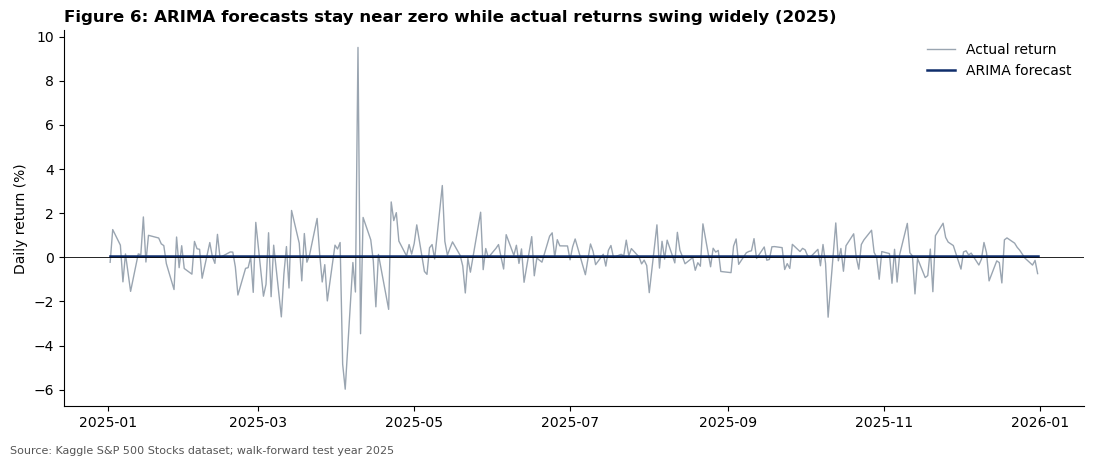

In [ ]:
FIG6_YEAR = 2025
p25 = P[P.index.year == FIG6_YEAR]
if len(p25):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(
        p25.index, p25["actual"] * 100, color="#9aa5b1", lw=1, label="Actual return"
    )
    ax.plot(
        p25.index, p25["ARIMA"] * 100, color="#0f2d6b", lw=1.8, label="ARIMA forecast"
    )
    ax.axhline(0, color="black", lw=0.6)
    ax.set_title(
        f"Figure 6: ARIMA forecasts stay near zero while actual returns swing widely ({FIG6_YEAR})",
        fontsize=12,
        fontweight="bold",
        loc="left",
    )
    ax.set_ylabel("Daily return (%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="upper right")
    fig.text(
        0.01,
        -0.02,
        f"Source: Kaggle S&P 500 Stocks dataset; walk-forward test year {FIG6_YEAR}",
        fontsize=8,
        color="#555",
    )
    fig.tight_layout()
    fig.savefig(
        f"{OUT}/fig6_arima_vs_actual_{FIG6_YEAR}.png", dpi=200, bbox_inches="tight"
    )
    plt.show()
else:
    print(f"No {FIG6_YEAR} data in the file.")

### Direction accuracy vs coin flip (all test years pooled)


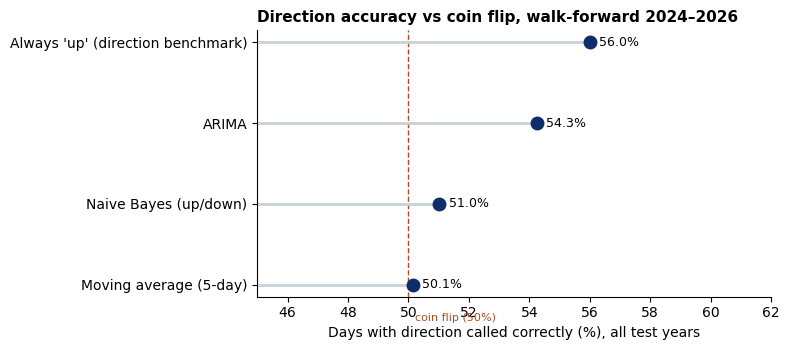

In [ ]:
d = table6.dropna(subset=["Direction %"]).sort_values("Direction %")
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.axvline(50, color="#b24a28", ls="--", lw=1)
ax.text(50.2, -0.45, "coin flip (50%)", color="#b24a28", fontsize=8)
ax.hlines(range(len(d)), 45, d["Direction %"], color="#c9d2d9", lw=2)
ax.plot(d["Direction %"], range(len(d)), "o", color="#0f2d6b", ms=9)
for i, v in enumerate(d["Direction %"]):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_yticks(range(len(d)), d["Model"])
ax.set_xlim(45, max(62, d["Direction %"].max() + 3))
ax.set_xlabel("Days with direction called correctly (%), all test years")
ax.set_title(
    f"Direction accuracy vs coin flip, walk-forward {TEST_YEARS[0]}–{TEST_YEARS[-1]}",
    fontsize=11,
    fontweight="bold",
    loc="left",
)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{OUT}/fig_direction_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()

### Direction accuracy by test year

Shows whether any model's edge holds up across years or is driven by one fold.


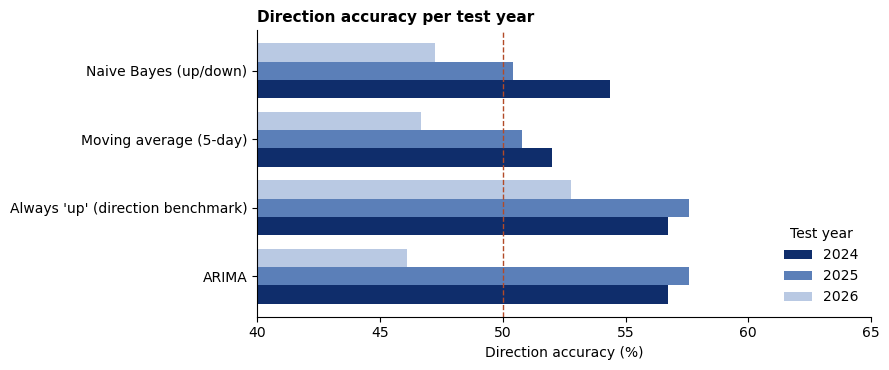

In [ ]:
dir_fold = by_fold.dropna(subset=["Direction %"]).pivot(
    index="Model", columns="test_year", values="Direction %"
)
fig, ax = plt.subplots(figsize=(9, 3.8))
n = len(dir_fold.columns)
width = 0.8 / n
colors = ["#0f2d6b", "#5b7fb8", "#b9c9e3"]
for j, yr in enumerate(dir_fold.columns):
    ax.barh(
        np.arange(len(dir_fold)) + (j - (n - 1) / 2) * width,
        dir_fold[yr],
        height=width,
        color=colors[j % len(colors)],
        label=str(yr),
    )
ax.axvline(50, color="#b24a28", ls="--", lw=1)
ax.set_yticks(range(len(dir_fold)), dir_fold.index)
ax.set_xlim(40, max(65, np.nanmax(dir_fold.values) + 3))
ax.set_xlabel("Direction accuracy (%)")
ax.set_title(
    "Direction accuracy per test year", fontsize=11, fontweight="bold", loc="left"
)
ax.legend(frameon=False, title="Test year", loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{OUT}/fig_direction_by_fold.png", dpi=200, bbox_inches="tight")
plt.show()

### RMSE by test year (error-based models)

Lower is better. Bars close to the naive bar mean the model adds little over predicting zero.


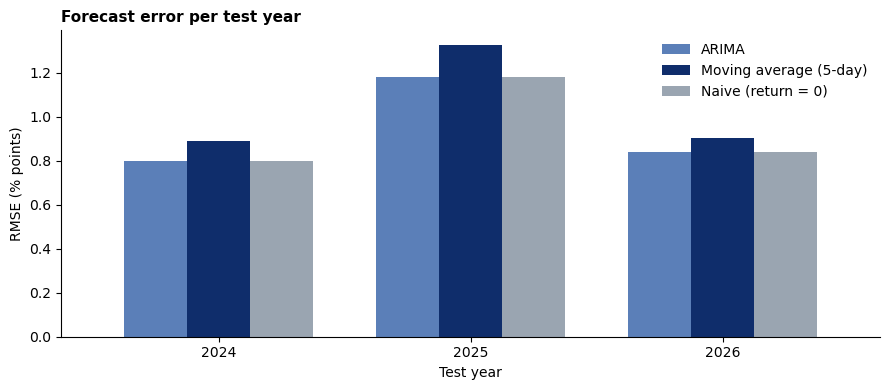

In [ ]:
rmse_fold = (
    by_fold.dropna(subset=["RMSE"]).pivot(
        index="test_year", columns="Model", values="RMSE"
    )
    * 100
)
ax = rmse_fold.plot(
    kind="bar",
    figsize=(9, 4),
    color=["#5b7fb8", "#0f2d6b", "#9aa5b1"],
    rot=0,
    width=0.75,
)
ax.set_ylabel("RMSE (% points)")
ax.set_xlabel("Test year")
ax.set_title("Forecast error per test year", fontsize=11, fontweight="bold", loc="left")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT}/fig_rmse_by_fold.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Files written


In [16]:
sorted(os.listdir(OUT))

['arima_orders.csv',
 'fig6_arima_vs_actual_2025.png',
 'fig_direction_accuracy.png',
 'fig_direction_by_fold.png',
 'fig_level_vs_return.png',
 'fig_rmse_by_fold.png',
 'stationarity.csv',
 'table6_by_fold.csv',
 'table6_results.csv']